<a href="https://colab.research.google.com/github/Rabia-Batool9/supervised-machine-learning-model/blob/main/rabia_batool_decission_tree5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DECISSION TREE

In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
df=pd.read_csv("/content/credit_data.csv")
df

,Age,Gender,Income,Credit Score,Credit History Length,Number of Existing Loans,Loan Amount,Loan Tenure,Existing Customer,State,City,LTV Ratio,Employment Profile,Profile Score,Occupation
0,31,Male,36000,604,487,5,109373,221,No,Karnataka,Mysuru,90.943430,Salaried,77,Doctor
1,25,Male,50000,447,386,2,150000,89,No,Karnataka,Bengaluru,91.135253,Salaried,43,Software Engineer
2,62,Other,178000,850,503,10,69099,110,Yes,Uttar Pradesh,Kanpur,40.000000,Salaried,90,Banker
3,69,Female,46000,668,349,6,150000,148,Yes,Karnataka,Bengaluru,87.393365,Self-Employed,86,Contractor
4,52,Male,132000,601,553,5,150000,157,No,Karnataka,Mysuru,66.158757,Salaried,90,Teacher
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279851,69,Male,61000,495,565,3,150000,14,No,Tamil Nadu,Chennai,90.300189,Salaried,71,Software Engineer
279852,45,Female,124000,850,476,10,80341,86,Yes,Karnataka,Bengaluru,78.960607,Salaried,91,Civil Servant
279853,33,Female,71000,582,560,5,39851,101,No,Karnataka,Mysuru,95.000000,Unemployed,57,NaN
279854,67,Male,191000,411,481,2,150000,111,No,Delhi,New Delhi,56.109002,Salaried,69,Software Engineer


In [5]:
df.shape

(279856, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279856 entries, 0 to 279855
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       279856 non-null  int64  
 1   Gender                    279856 non-null  object 
 2   Income                    279856 non-null  int64  
 3   Credit Score              279856 non-null  int64  
 4   Credit History Length     279856 non-null  int64  
 5   Number of Existing Loans  279856 non-null  int64  
 6   Loan Amount               279856 non-null  int64  
 7   Loan Tenure               279856 non-null  int64  
 8   Existing Customer         279856 non-null  object 
 9   State                     279856 non-null  object 
 10  City                      279856 non-null  object 
 11  LTV Ratio                 279856 non-null  float64
 12  Employment Profile        279856 non-null  object 
 13  Profile Score             279856 non-null  i

In [7]:
df.describe()

,Age,Income,Credit Score,Credit History Length,Number of Existing Loans,Loan Amount,Loan Tenure,LTV Ratio,Profile Score
count,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000,279856.000000
mean,44.005217,76499.163856,582.953773,307.965146,4.701693,105795.342773,133.340654,71.643101,77.350155
std,15.311051,42875.575193,163.076754,175.083268,2.980351,40458.370929,96.064132,16.865785,24.509196
min,18.000000,9000.000000,300.000000,6.000000,0.000000,5294.000000,12.000000,40.000000,0.000000
25%,31.000000,42000.000000,446.000000,156.000000,2.000000,72173.000000,62.000000,58.105848,61.000000
50%,44.000000,68000.000000,584.000000,307.000000,5.000000,111263.000000,100.000000,72.133017,89.000000
75%,57.000000,104000.000000,722.000000,460.000000,7.000000,150000.000000,201.000000,86.239725,98.000000
max,70.000000,209000.000000,850.000000,611.000000,10.000000,150000.000000,359.000000,95.000000,100.000000


In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
Income,0
Credit Score,0
Credit History Length,0
Number of Existing Loans,0
Loan Amount,0
Loan Tenure,0
Existing Customer,0
State,0


In [9]:
df.drop(columns=["Occupation"], inplace=True)

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [11]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'Income': 863, 'Credit Score': 0, 'Credit History Length': 0, 'Number of Existing Loans': 0, 'Loan Amount': 0, 'Loan Tenure': 0, 'LTV Ratio': 0, 'Profile Score': 1670}


In [12]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

                     Column  Outlier_Count
8             Profile Score           1670
1                    Income            863
0                       Age              0
3     Credit History Length              0
2              Credit Score              0
4  Number of Existing Loans              0
5               Loan Amount              0
6               Loan Tenure              0
7                 LTV Ratio              0


In [13]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

                     Column  Outlier_Count  Percentage
8             Profile Score           1670    0.596735
1                    Income            863    0.308373
0                       Age              0    0.000000
3     Credit History Length              0    0.000000
2              Credit Score              0    0.000000
4  Number of Existing Loans              0    0.000000
5               Loan Amount              0    0.000000
6               Loan Tenure              0    0.000000
7                 LTV Ratio              0    0.000000


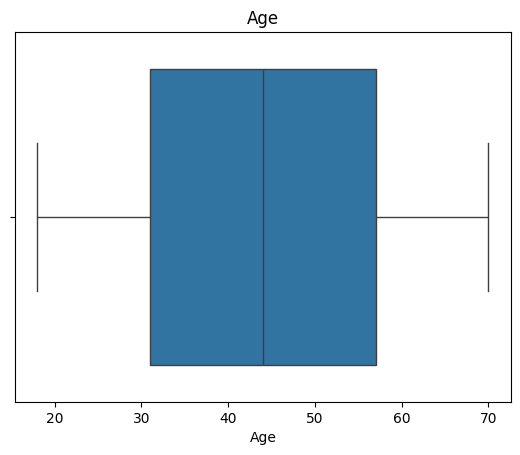

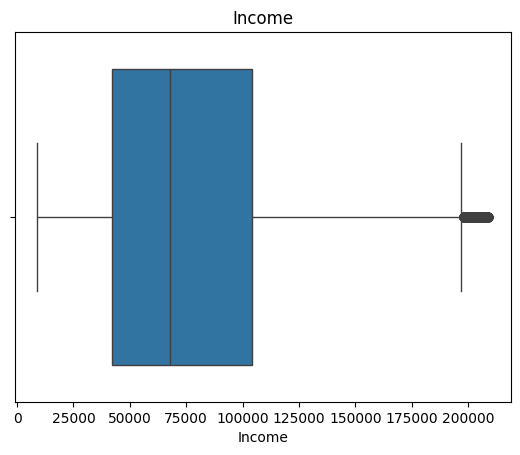

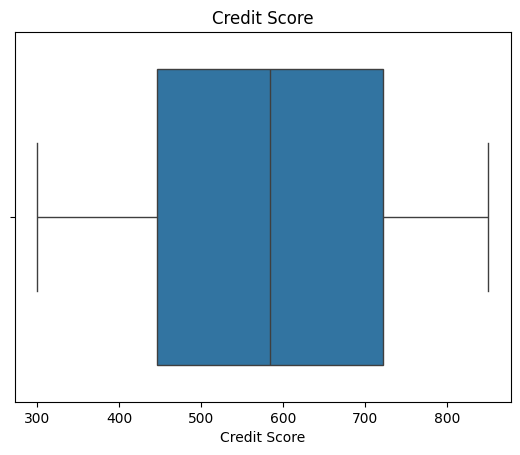

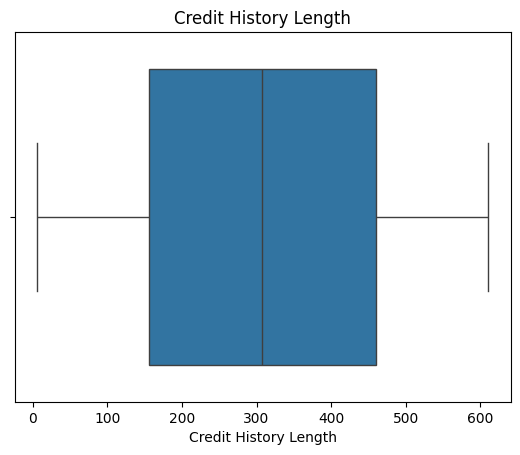

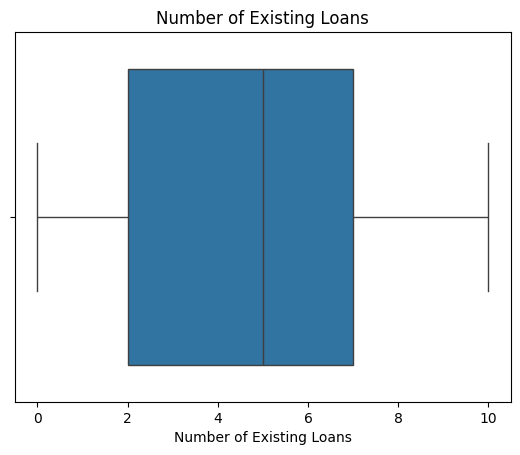

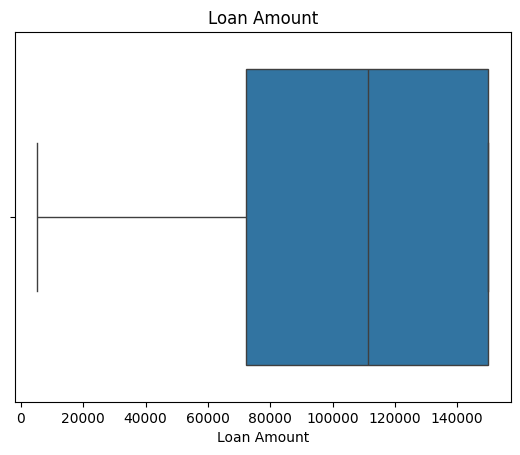

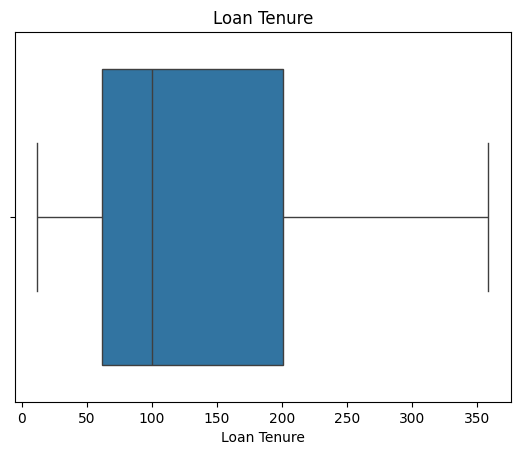

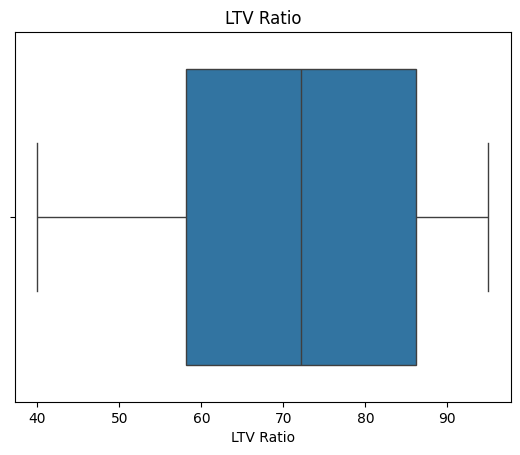

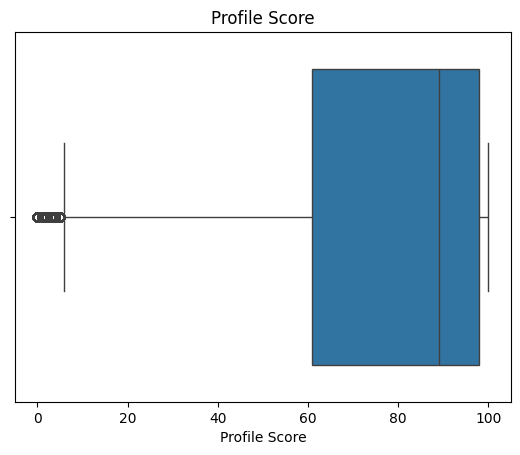

In [14]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [15]:
cols_to_cap = [
    'Income',
    'Loan Amount',
    'LTV Ratio',
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [16]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

                     Column  Outlier_Count
8             Profile Score           1670
1                    Income            863
0                       Age              0
3     Credit History Length              0
2              Credit Score              0
4  Number of Existing Loans              0
5               Loan Amount              0
6               Loan Tenure              0
7                 LTV Ratio              0


In [17]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

                     Column  Outlier_Count  Percentage
8             Profile Score           1670    0.596735
1                    Income            863    0.308373
0                       Age              0    0.000000
3     Credit History Length              0    0.000000
2              Credit Score              0    0.000000
4  Number of Existing Loans              0    0.000000
5               Loan Amount              0    0.000000
6               Loan Tenure              0    0.000000
7                 LTV Ratio              0    0.000000


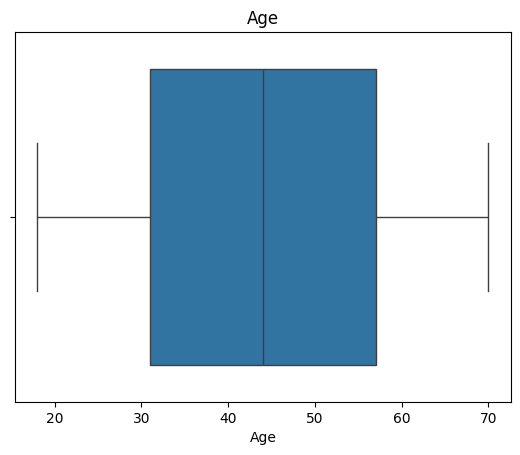

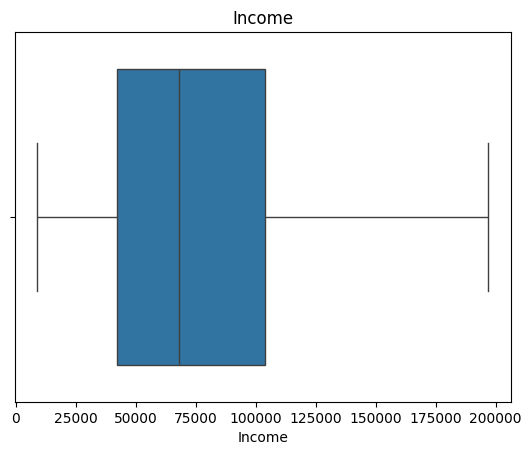

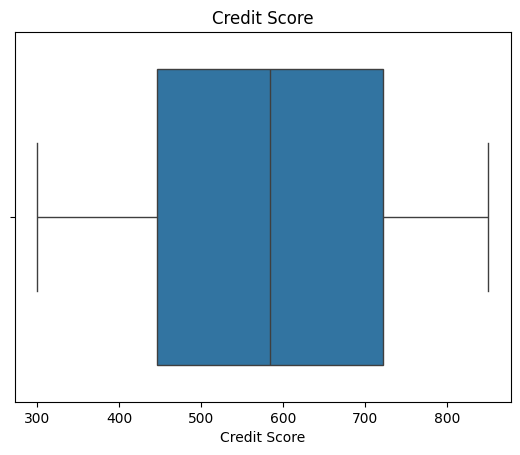

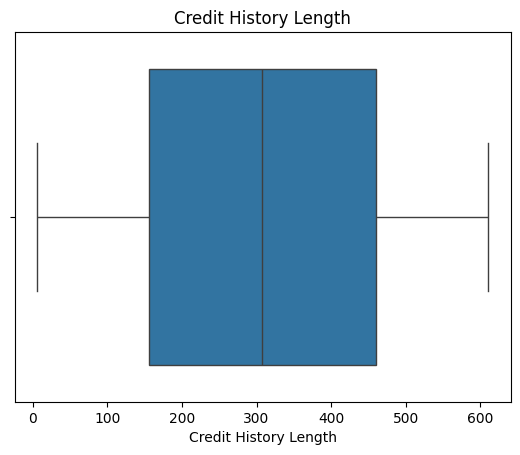

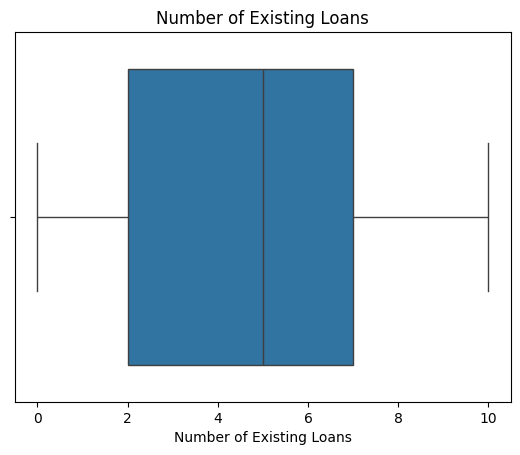

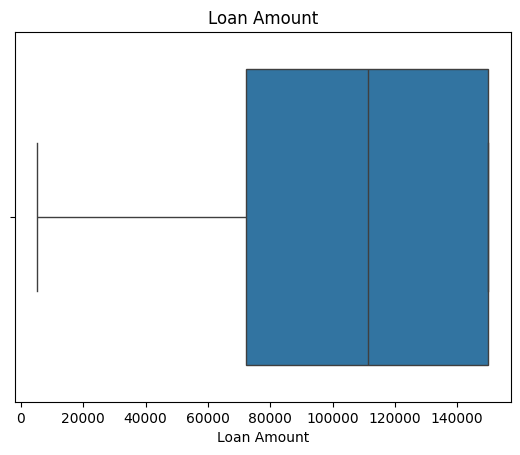

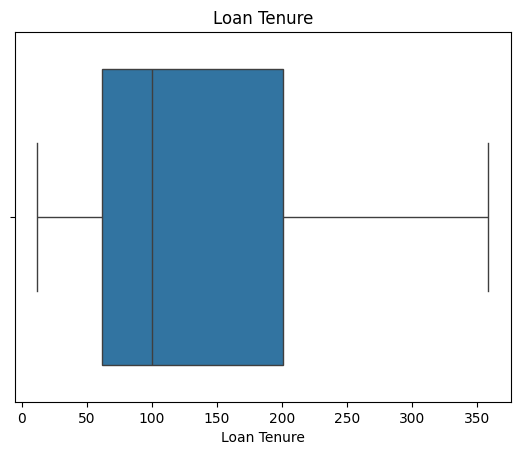

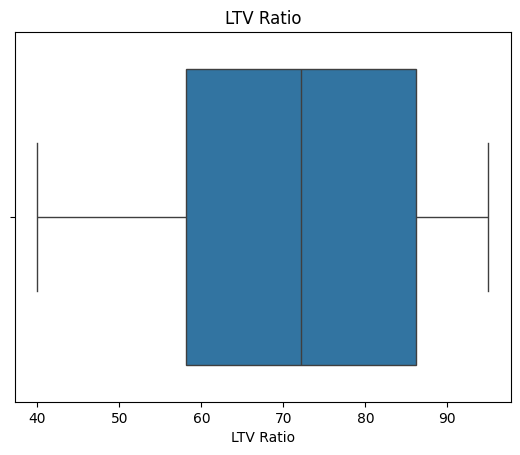

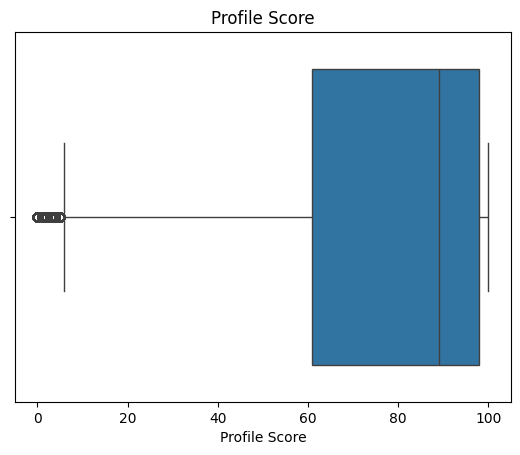

In [18]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [19]:
cols_to_cap = [
    'Income',
    'Loan Amount',
    'LTV Ratio',
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

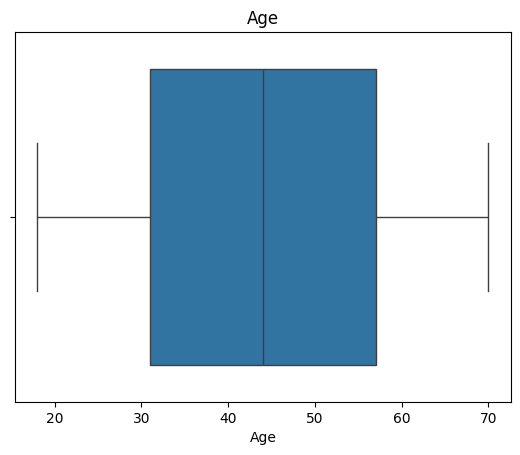

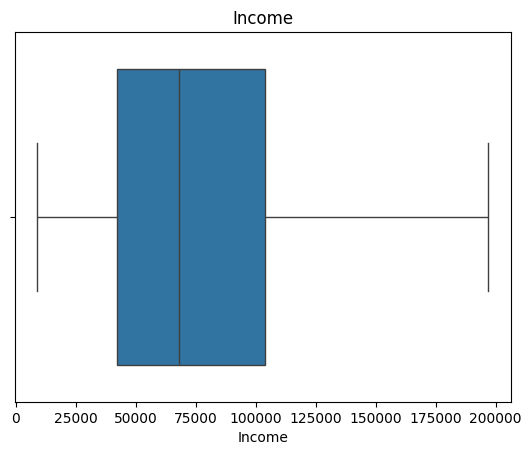

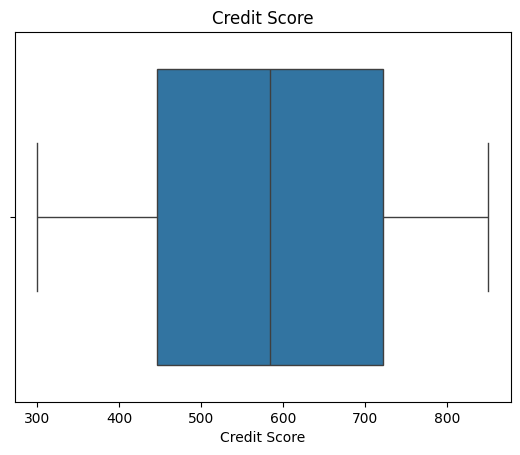

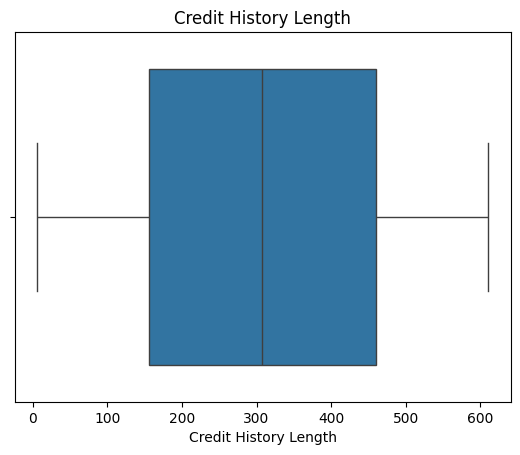

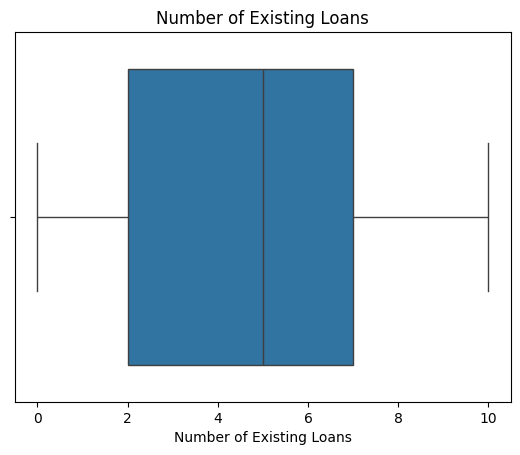

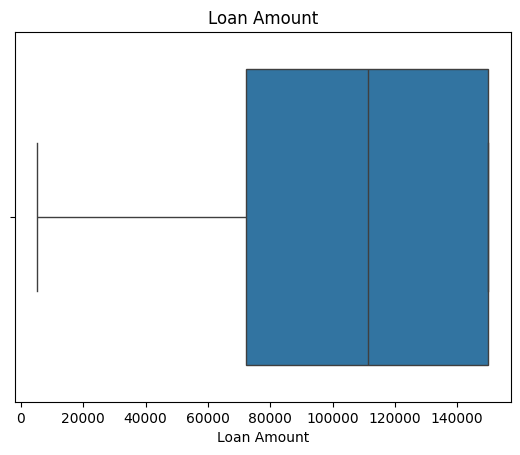

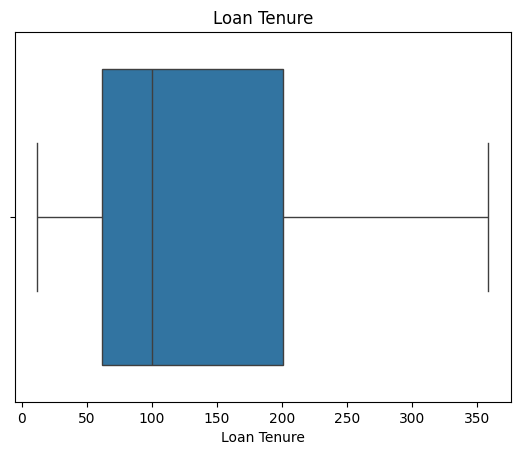

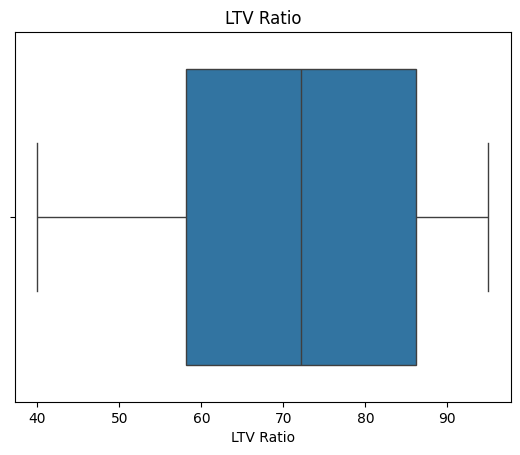

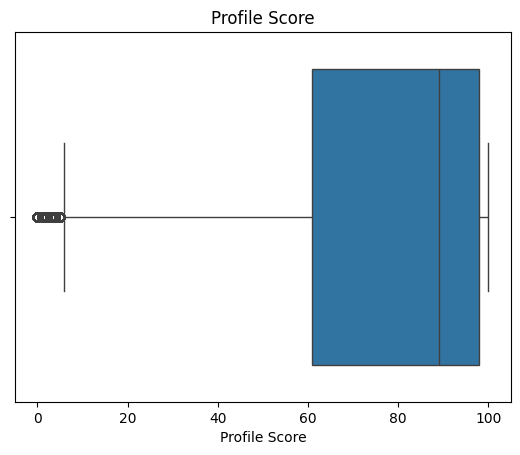

In [20]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

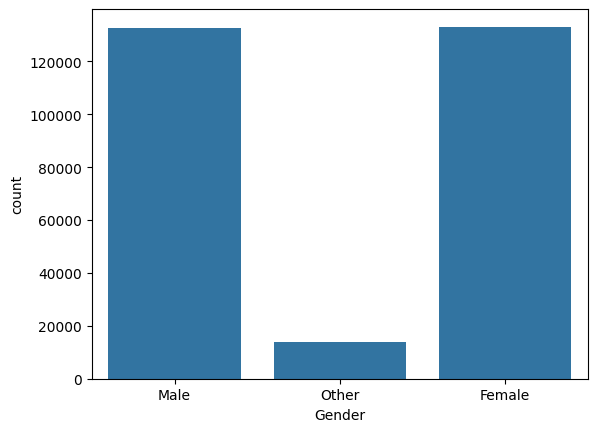

In [21]:
sns.countplot(x=df["Gender"])
plt.show()

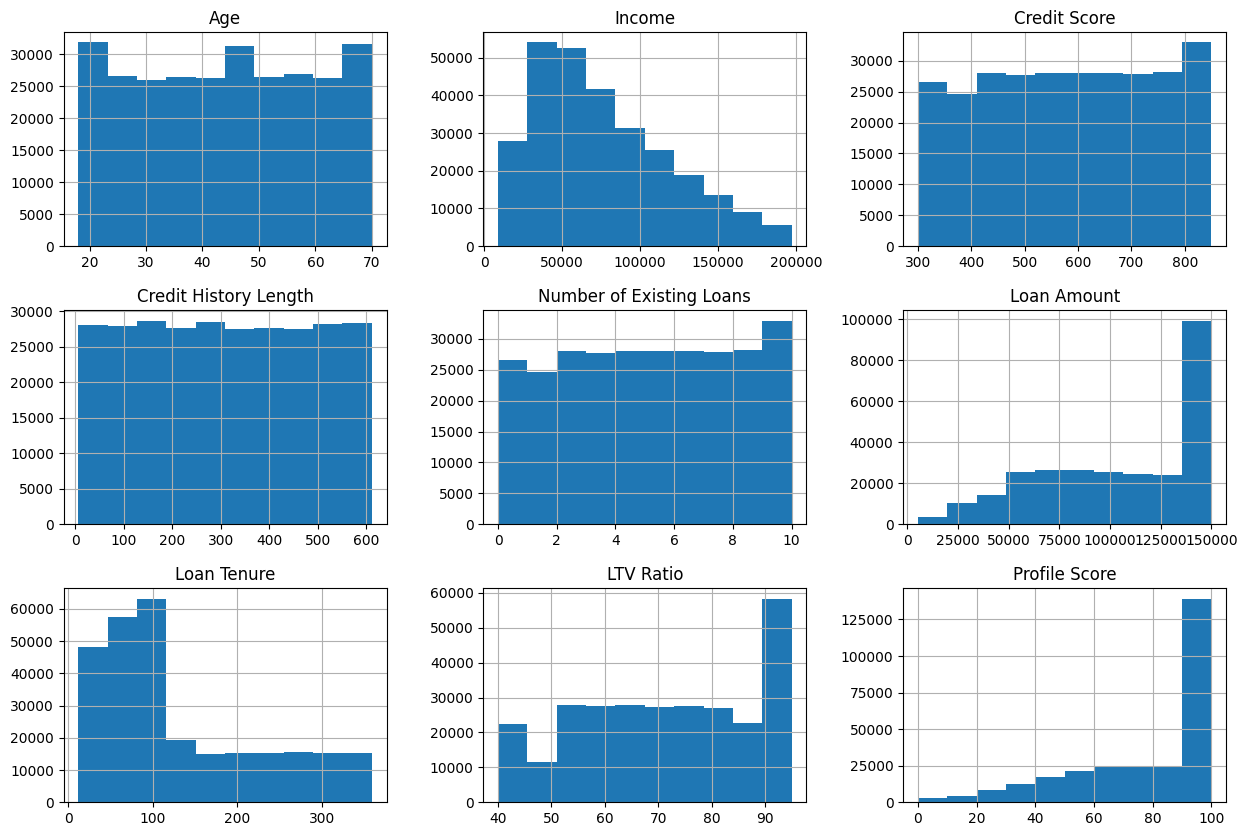

In [22]:
df.hist(figsize=(15,10))
plt.show()

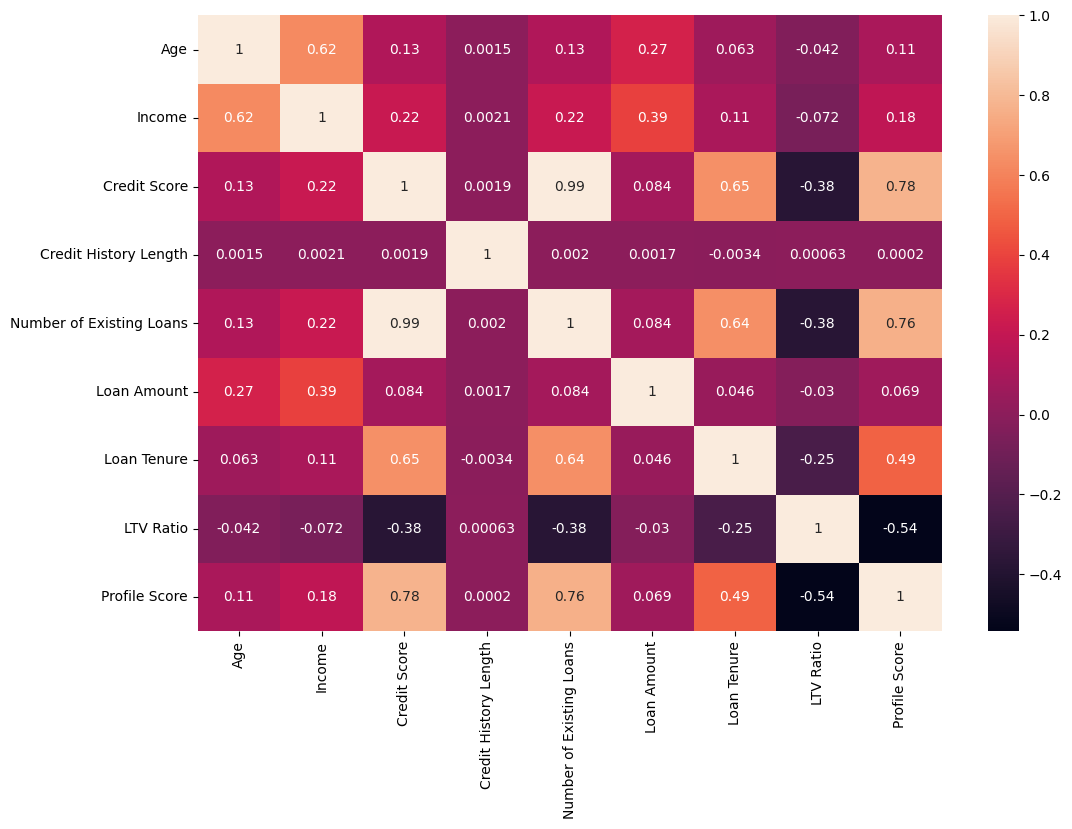

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

In [25]:
X = df.drop("Existing Customer", axis=1)
y = df["Existing Customer"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns after one-hot encoding
X_train, X_test = X_train.align(X_test, join='outer', axis=1, fill_value=0)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [29]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [30]:
accuracy_score(y_test, y_pred_dt)

1.0

In [31]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00     34791
         Yes       1.00      1.00      1.00     21181

    accuracy                           1.00     55972
   macro avg       1.00      1.00      1.00     55972
weighted avg       1.00      1.00      1.00     55972



In [32]:
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)

[[34791     0]
 [    0 21181]]


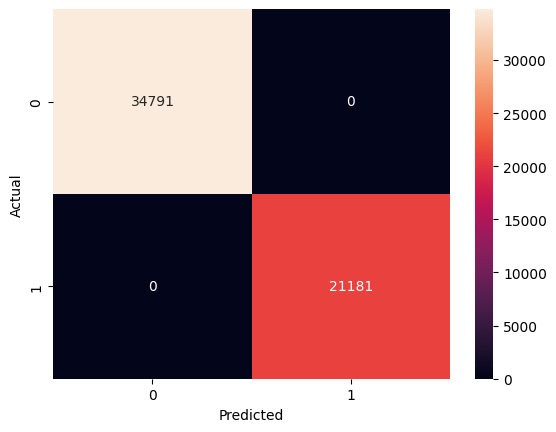

In [33]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
# Recreate the DataFrame with one-hot encoded columns to match the features used in the model
# The original X has fewer columns than the features the model was trained on due to one-hot encoding.
# We need to get the column names corresponding to the features dt was trained on (after one-hot encoding).

# Generate dummy variables for the full X DataFrame to get the correct column names
X_processed_columns = pd.get_dummies(X, drop_first=True).columns

importance = pd.DataFrame({
    "Feature": X_processed_columns,
    "Importance": dt.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,Credit Score,1.0
0,Age,0.0
1,Income,0.0
3,Credit History Length,0.0
4,Number of Existing Loans,0.0
5,Loan Amount,0.0
6,Loan Tenure,0.0
7,LTV Ratio,0.0
8,Profile Score,0.0
9,Gender_Male,0.0


In [36]:
train_acc = dt.score(X_train, y_train)

test_acc = dt.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [37]:
dt.get_depth()

1

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns from the original X
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor that applies OneHotEncoder to categorical and StandardScaler to numerical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any
)

# Create a pipeline that first preprocesses the data and then applies the Decision Tree Classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Now use cross_val_score with the pipeline and the original X and y
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
1.0


In [41]:
from sklearn.metrics import roc_auc_score

# Map 'No' to 0 and 'Yes' to 1 for both y_test and y_pred_dt
y_test_numeric = y_test.map({'No': 0, 'Yes': 1})
y_pred_dt_numeric = pd.Series(y_pred_dt).map({'No': 0, 'Yes': 1})

roc_auc_score(y_test_numeric, y_pred_dt_numeric)

np.float64(1.0)

In [43]:
from sklearn.metrics import roc_curve, auc

y_prob = dt.predict_proba(X_test)[:,1]
y_test_numeric = y_test.map({'No': 0, 'Yes': 1})
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_prob)

In [44]:
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 1.0


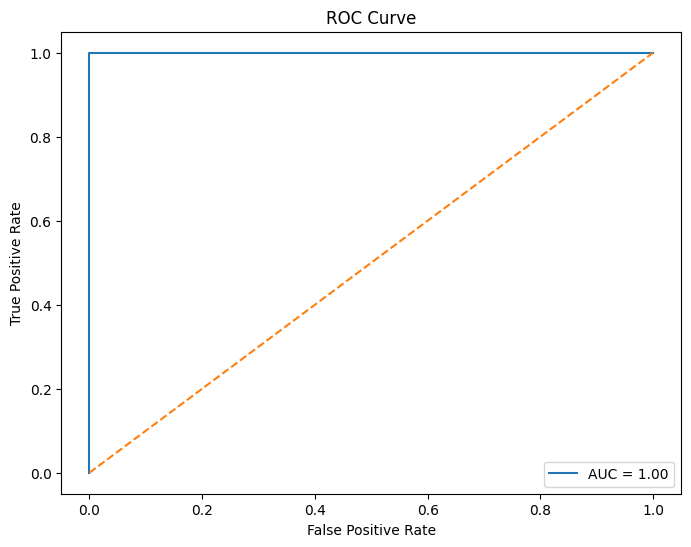

In [45]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [46]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [47]:
accuracy_score(y_test, y_pred_rf)

1.0

In [48]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00     34791
         Yes       1.00      1.00      1.00     21181

    accuracy                           1.00     55972
   macro avg       1.00      1.00      1.00     55972
weighted avg       1.00      1.00      1.00     55972



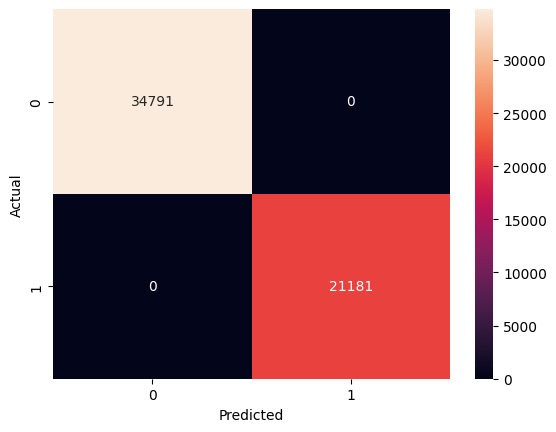

In [49]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
X_processed_columns_rf = pd.get_dummies(X, drop_first=True).columns
importance = pd.DataFrame({
    "Feature": X_processed_columns_rf,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,Credit Score,0.402689
4,Number of Existing Loans,0.318356
6,Loan Tenure,0.129614
8,Profile Score,0.100744
7,LTV Ratio,0.043166
1,Income,0.002990
0,Age,0.000947
42,Employment Profile_Salaried,0.000380
5,Loan Amount,0.000342
3,Credit History Length,0.000168


In [52]:
train_acc = rf.score(X_train, y_train)

test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [53]:
dt.get_depth()

1

In [55]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns from the original X
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor that applies OneHotEncoder to categorical and StandardScaler to numerical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any
)

# Create a pipeline that first preprocesses the data and then applies the RandomForestClassifier
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf) # Use the already defined rf model
])

# Now use cross_val_score with the pipeline and the original X and y
scores = cross_val_score(
    pipeline_rf,
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
1.0


In [57]:
from sklearn.metrics import roc_auc_score

# Map 'No' to 0 and 'Yes' to 1 for both y_test and y_pred_rf
y_test_numeric = y_test.map({'No': 0, 'Yes': 1})
y_pred_rf_numeric = pd.Series(y_pred_rf).map({'No': 0, 'Yes': 1})

roc_auc_score(y_test_numeric, y_pred_rf_numeric)

np.float64(1.0)

In [59]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_prob)

In [60]:
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 1.0


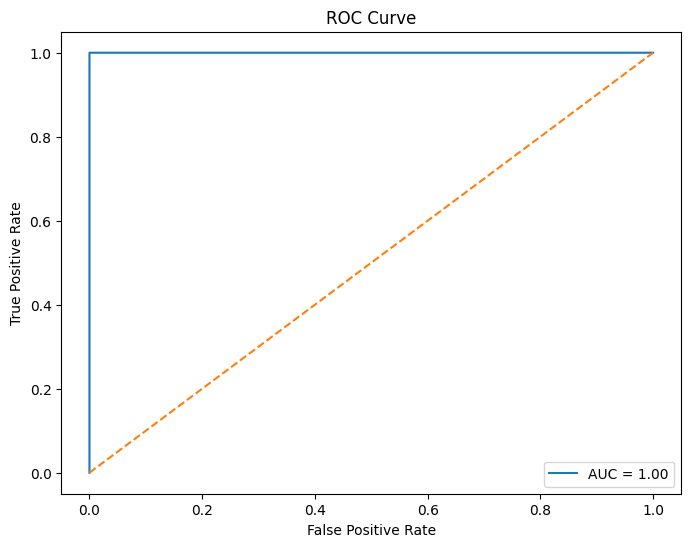

In [61]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()